# 06 — Mejoras v2: Nuevas Features, Umbral Óptimo y Focal Loss

**Objetivo:** mejorar los resultados de la v1 mediante:

1. **Nuevas features** con alto poder predictivo (`dias_estimados`, `dias_limite_envio`, `mismo_estado`, `n_items`)
2. **Umbral óptimo** para clasificación (en lugar de 0.5 fijo)
3. **Focal Loss** para combatir el desbalance de clases en clasificación

Los modelos anteriores se conservan como baseline. Este notebook genera modelos `_v2` y una tabla comparativa final.

**Baseline (v1):** MAE=3.26d · R²=0.15 · AUC=0.56 · F1=0.03

In [15]:
import pandas as pd
import numpy as np
import pickle
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, precision_recall_curve, RocCurveDisplay
)

print('TensorFlow:', tf.__version__)
sns.set_theme(style='whitegrid')

DATA_DIR     = Path('../dataset')
PROC_DIR     = Path('../data/processed')
MODELS_DIR   = Path('../models')
OUTPUTS_DIR  = Path('../outputs')
GRAFICAS_DIR = Path('../outputs/graficas')
OUT_DIR      = GRAFICAS_DIR  # alias

# Crear directorios si no existen
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
GRAFICAS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

TensorFlow: 2.21.0


## 1. Carga de datos y construcción del dataset v2

In [16]:
orders = pd.read_csv(DATA_DIR / 'olist_orders_dataset.csv', parse_dates=[
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])
items     = pd.read_csv(DATA_DIR / 'olist_order_items_dataset.csv',
                        parse_dates=['shipping_limit_date'])
products  = pd.read_csv(DATA_DIR / 'olist_products_dataset.csv')
customers = pd.read_csv(DATA_DIR / 'olist_customers_dataset.csv')
sellers   = pd.read_csv(DATA_DIR / 'olist_sellers_dataset.csv')
geo       = pd.read_csv(DATA_DIR / 'olist_geolocation_dataset.csv')
cat_names = pd.read_csv(DATA_DIR / 'product_category_name_translation.csv')

print('Datos cargados.')

Datos cargados.


In [17]:
# Filtrar órdenes entregadas válidas
df = orders[
    (orders['order_status'] == 'delivered') &
    orders['order_delivered_customer_date'].notna()
].copy()

# --- Targets ---
df['dias_entrega'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days
df['es_retraso'] = (
    df['order_delivered_customer_date'] > df['order_estimated_delivery_date']
).astype(int)

# Eliminar outliers
df = df[(df['dias_entrega'] >= 0) & (df['dias_entrega'] <= 60)]

# --- NUEVA FEATURE 1: dias_estimados ---
# La plataforma ya calcula su propia estimación al momento del pedido
df['dias_estimados'] = (
    df['order_estimated_delivery_date'] - df['order_purchase_timestamp']
).dt.days

print(f'Órdenes válidas: {len(df):,}')
print(f'Correlación dias_estimados vs dias_entrega: '
      f'{df["dias_estimados"].corr(df["dias_entrega"]):.3f}')

Órdenes válidas: 96,182
Correlación dias_estimados vs dias_entrega: 0.419


In [18]:
# Features temporales
df['mes_compra']        = df['order_purchase_timestamp'].dt.month
df['dia_semana_compra'] = df['order_purchase_timestamp'].dt.dayofweek
df['hora_compra']       = df['order_purchase_timestamp'].dt.hour

# Join items (agregar por orden)
items_agg = items.sort_values('price', ascending=False).groupby('order_id').agg(
    precio_total        = ('price', 'sum'),
    flete_total         = ('freight_value', 'sum'),
    product_id          = ('product_id', 'first'),
    seller_id           = ('seller_id', 'first'),
    n_items             = ('order_item_id', 'count'),           # NUEVA FEATURE 2
    shipping_limit_date = ('shipping_limit_date', 'first')     # para dias_limite_envio
).reset_index()

df = df.merge(items_agg, on='order_id', how='left')

# --- NUEVA FEATURE 3: dias_limite_envio ---
# Plazo que tiene el seller para enviar al carrier desde la compra
df['dias_limite_envio'] = (
    df['shipping_limit_date'] - df['order_purchase_timestamp']
).dt.days.clip(lower=0)

# Join productos
products = products.merge(cat_names, on='product_category_name', how='left')
df = df.merge(
    products[['product_id', 'product_category_name_english',
              'product_weight_g', 'product_length_cm',
              'product_height_cm', 'product_width_cm']],
    on='product_id', how='left'
)
df.rename(columns={'product_category_name_english': 'categoria_producto'}, inplace=True)
df['volumen_cm3'] = df['product_length_cm'] * df['product_height_cm'] * df['product_width_cm']

# Join sellers y clientes
df = df.merge(sellers[['seller_id', 'seller_zip_code_prefix', 'seller_state']],
              on='seller_id', how='left')
df = df.merge(customers[['customer_id', 'customer_zip_code_prefix', 'customer_state']],
              on='customer_id', how='left')

# --- NUEVA FEATURE 4: mismo_estado ---
df['mismo_estado'] = (df['seller_state'] == df['customer_state']).astype(int)

print(df[['dias_estimados', 'dias_limite_envio', 'n_items', 'mismo_estado']].describe())

       dias_estimados  dias_limite_envio       n_items  mismo_estado
count    96182.000000       96182.000000  96182.000000  96182.000000
mean        23.354651           6.396114      1.142397      0.360255
std          8.741688           4.627411      0.539281      0.480077
min          2.000000           2.000000      1.000000      0.000000
25%         18.000000           5.000000      1.000000      0.000000
50%         23.000000           6.000000      1.000000      0.000000
75%         28.000000           7.000000      1.000000      1.000000
max        155.000000        1052.000000     21.000000      1.000000


In [19]:
# Coordenadas para Haversine
geo_agg = geo.groupby('geolocation_zip_code_prefix').agg(
    lat=('geolocation_lat', 'median'),
    lng=('geolocation_lng', 'median')
).reset_index()

df = df.merge(
    geo_agg.rename(columns={'geolocation_zip_code_prefix': 'seller_zip_code_prefix',
                            'lat': 'seller_lat', 'lng': 'seller_lng'}),
    on='seller_zip_code_prefix', how='left'
)
df = df.merge(
    geo_agg.rename(columns={'geolocation_zip_code_prefix': 'customer_zip_code_prefix',
                            'lat': 'customer_lat', 'lng': 'customer_lng'}),
    on='customer_zip_code_prefix', how='left'
)

def haversine(lat1, lng1, lat2, lng2):
    R = 6371.0
    lat1, lng1, lat2, lng2 = map(np.radians, [lat1, lng1, lat2, lng2])
    dlat = lat2 - lat1
    dlng = lng2 - lng1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlng/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df['distancia_km'] = haversine(
    df['seller_lat'], df['seller_lng'],
    df['customer_lat'], df['customer_lng']
)

print(f'Distancia media: {df["distancia_km"].mean():.1f} km')

Distancia media: 599.4 km


## 2. Preparar dataset v2 y split cronológico

In [20]:
# Features v2: las 8 originales + 4 nuevas
FEATURES_NUM_V2 = [
    'distancia_km', 'precio_total', 'flete_total',
    'product_weight_g', 'volumen_cm3',
    'mes_compra', 'dia_semana_compra', 'hora_compra',
    # Nuevas features v2
    'dias_estimados', 'dias_limite_envio', 'n_items', 'mismo_estado'
]
FEATURES_CAT = ['categoria_producto', 'customer_state', 'seller_state']
TARGETS      = ['dias_entrega', 'es_retraso']

df_modelo = df[FEATURES_NUM_V2 + FEATURES_CAT + TARGETS + ['order_purchase_timestamp']].copy()

# Imputar nulos
for col in FEATURES_NUM_V2:
    df_modelo[col] = df_modelo[col].fillna(df_modelo[col].median())
for col in FEATURES_CAT:
    df_modelo[col] = df_modelo[col].fillna('desconocido')

print(f'Dataset v2: {df_modelo.shape}')
print(f'Nulos restantes: {df_modelo.isnull().sum().sum()}')

Dataset v2: (96182, 18)
Nulos restantes: 0


In [21]:
# Split cronológico 80/10/10
df_modelo = df_modelo.sort_values('order_purchase_timestamp').reset_index(drop=True)
n = len(df_modelo)
n_train, n_val = int(n * 0.80), int(n * 0.90)

train = df_modelo.iloc[:n_train].copy()
val   = df_modelo.iloc[n_train:n_val].copy()
test  = df_modelo.iloc[n_val:].copy()

print(f'Train: {len(train):,} | Val: {len(val):,} | Test: {len(test):,}')

# Escalar numéricas
scaler_v2 = StandardScaler()
train[FEATURES_NUM_V2] = scaler_v2.fit_transform(train[FEATURES_NUM_V2])
val[FEATURES_NUM_V2]   = scaler_v2.transform(val[FEATURES_NUM_V2])
test[FEATURES_NUM_V2]  = scaler_v2.transform(test[FEATURES_NUM_V2])

# Codificar categóricas
encoders_v2 = {}
cardinalidades_v2 = {}
for col in FEATURES_CAT:
    le = LabelEncoder()
    le.fit(train[col])
    for split in [train, val, test]:
        split[col] = split[col].apply(lambda x: x if x in le.classes_ else 'desconocido')
    train[col] = le.transform(train[col])
    val[col]   = le.transform(val[col])
    test[col]  = le.transform(test[col])
    encoders_v2[col] = le
    cardinalidades_v2[col] = len(le.classes_)

print(f'Cardinalidades: {cardinalidades_v2}')

Train: 76,945 | Val: 9,618 | Test: 9,619
Cardinalidades: {'categoria_producto': 72, 'customer_state': 27, 'seller_state': 22}


In [22]:
# Preparar arrays de inputs
def preparar_inputs(df, features_num, features_cat):
    X_num = df[features_num].values.astype('float32')
    X_cat = [df[col].values.astype('int32') for col in features_cat]
    return [X_num] + X_cat

X_train = preparar_inputs(train, FEATURES_NUM_V2, FEATURES_CAT)
X_val   = preparar_inputs(val,   FEATURES_NUM_V2, FEATURES_CAT)
X_test  = preparar_inputs(test,  FEATURES_NUM_V2, FEATURES_CAT)

y_train_reg = train['dias_entrega'].values.astype('float32')
y_val_reg   = val['dias_entrega'].values.astype('float32')
y_test_reg  = test['dias_entrega'].values.astype('float32')

y_train_clf = train['es_retraso'].values.astype('float32')
y_val_clf   = val['es_retraso'].values.astype('float32')
y_test_clf  = test['es_retraso'].values.astype('float32')

## 3. Arquitectura base (compartida por ambos modelos)

In [23]:
def construir_base(cards, n_num, nombre_salida, activacion_salida):
    """
    Arquitectura Feed-Forward con Embeddings reutilizable.
    Parámetros:
        cards: dict {col: cardinalidad}
        n_num: número de features numéricas
        nombre_salida: nombre de la capa de salida
        activacion_salida: 'linear' para regresión, 'sigmoid' para clasificación
    """
    inp_num = keras.Input(shape=(n_num,), name='input_numerico')

    emb_inputs, emb_outputs = [], []
    for col, card in cards.items():
        dim = min(50, (card // 2) + 1)
        inp = keras.Input(shape=(1,), name=f'input_{col}', dtype='int32')
        emb = layers.Embedding(input_dim=card, output_dim=dim, name=f'emb_{col}')(inp)
        emb = layers.Flatten()(emb)
        emb_inputs.append(inp)
        emb_outputs.append(emb)

    x = layers.Concatenate()([inp_num] + emb_outputs)

    for unidades in [256, 128, 64]:
        x = layers.Dense(unidades, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3 if unidades == 256 else 0.2)(x)

    salida = layers.Dense(1, activation=activacion_salida, name=nombre_salida)(x)

    return keras.Model(inputs=[inp_num] + emb_inputs, outputs=salida)

## 4. Modelo de Regresión v2

In [24]:
modelo_reg_v2 = construir_base(
    cardinalidades_v2, n_num=len(FEATURES_NUM_V2),
    nombre_salida='dias_entrega', activacion_salida='linear'
)

modelo_reg_v2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mae', metrics=['mae']
)

callbacks_reg = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, verbose=1
    )
]

historia_reg = modelo_reg_v2.fit(
    X_train, y_train_reg,
    validation_data=(X_val, y_val_reg),
    epochs=100, batch_size=256,
    callbacks=callbacks_reg, verbose=1
)

Epoch 1/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 9.2003 - mae: 9.2003 - val_loss: 3.5043 - val_mae: 3.5043 - learning_rate: 0.0010
Epoch 2/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 5.1548 - mae: 5.1548 - val_loss: 3.6619 - val_mae: 3.6619 - learning_rate: 0.0010
Epoch 3/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5.0316 - mae: 5.0316 - val_loss: 3.5884 - val_mae: 3.5884 - learning_rate: 0.0010
Epoch 4/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 4.9621 - mae: 4.9621 - val_loss: 3.5226 - val_mae: 3.5226 - learning_rate: 0.0010
Epoch 5/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 4.9262 - mae: 4.9262 - val_loss: 3.5607 - val_mae: 3.5607 - learning_rate: 0.0010
Epoch 6/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 4.8884 - mae: 4.8884 - val_loss: 3.4830 - val_mae: 3.4830 - learning_rate: 0.0010
Epoch 7/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 4.8616 - mae: 4.8616 - val_loss: 3.4786 - val_mae: 3.4786 - learning_rate: 0.001

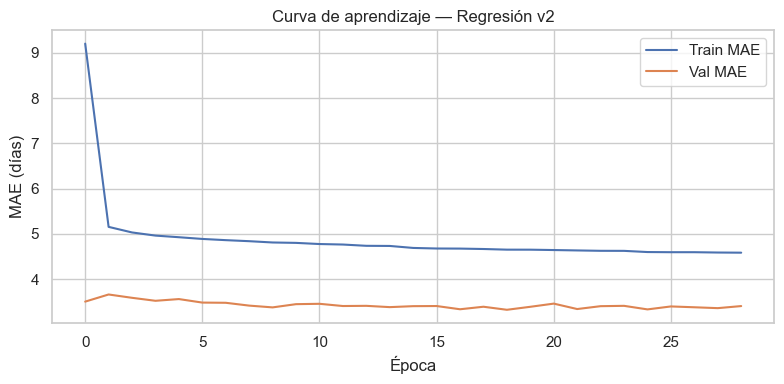

301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
=== Regresión v2 ===
  MAE:  2.78 días
  RMSE: 4.08 días
  R²:   0.2700


In [25]:
plt.figure(figsize=(8, 4))
plt.plot(historia_reg.history['loss'],     label='Train MAE')
plt.plot(historia_reg.history['val_loss'], label='Val MAE')
plt.title('Curva de aprendizaje — Regresión v2')
plt.xlabel('Época')
plt.ylabel('MAE (días)')
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'curva_regresion_v2.png', dpi=100)
plt.show()

# Métricas en test
pred_dias_v2 = modelo_reg_v2.predict(X_test).flatten()
mae_v2  = mean_absolute_error(y_test_reg, pred_dias_v2)
rmse_v2 = np.sqrt(mean_squared_error(y_test_reg, pred_dias_v2))
r2_v2   = r2_score(y_test_reg, pred_dias_v2)

print('=== Regresión v2 ===')
print(f'  MAE:  {mae_v2:.2f} días')
print(f'  RMSE: {rmse_v2:.2f} días')
print(f'  R²:   {r2_v2:.4f}')

In [26]:
modelo_reg_v2.save(MODELS_DIR / 'modelo_regresion_v2.keras')
print('Guardado: models/modelo_regresion_v2.keras')

Guardado: models/modelo_regresion_v2.keras


## 5. Modelo de Clasificación v2 con Focal Loss

La **Focal Loss** penaliza más los ejemplos difíciles (retrasos que el modelo confunde) reduciendo el peso de los ejemplos fáciles (entregas a tiempo bien clasificadas). Es más efectiva que `class_weight` para datasets muy desbalanceados.

$$FL(p_t) = -\alpha_t (1 - p_t)^\gamma \log(p_t)$$

- $\gamma$ (focusing parameter): valor típico 2.0
- $\alpha$: peso para la clase positiva (retraso), típicamente inverso a su frecuencia

In [27]:
# Focal Loss como función custom de Keras
def focal_loss(gamma=2.0, alpha=0.75):
    """
    gamma: parámetro de foco (penaliza más los ejemplos difíciles)
    alpha: peso para la clase positiva (retraso)
    """
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        focal_factor = tf.pow(1 - p_t, gamma)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        return tf.reduce_mean(alpha_t * focal_factor * bce)
    return loss


modelo_clf_v2 = construir_base(
    cardinalidades_v2, n_num=len(FEATURES_NUM_V2),
    nombre_salida='es_retraso', activacion_salida='sigmoid'
)

modelo_clf_v2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=focal_loss(gamma=2.0, alpha=0.75),
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

callbacks_clf = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=10,
        restore_best_weights=True, mode='max', verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, verbose=1
    )
]

historia_clf = modelo_clf_v2.fit(
    X_train, y_train_clf,
    validation_data=(X_val, y_val_clf),
    epochs=100, batch_size=256,
    callbacks=callbacks_clf, verbose=1
)

Epoch 1/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7760 - auc: 0.5911 - loss: 0.0521 - val_accuracy: 0.9813 - val_auc: 0.7169 - val_loss: 0.0186 - learning_rate: 0.0010
Epoch 2/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8713 - auc: 0.6729 - loss: 0.0391 - val_accuracy: 0.9759 - val_auc: 0.7720 - val_loss: 0.0164 - learning_rate: 0.0010
Epoch 3/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8858 - auc: 0.7142 - loss: 0.0364 - val_accuracy: 0.9737 - val_auc: 0.7864 - val_loss: 0.0153 - learning_rate: 0.0010
Epoch 4/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8919 - auc: 0.7320 - loss: 0.0354 - val_accuracy: 0.9775 - val_auc: 0.7836 - val_loss: 0.0154 - learning_rate: 0.0010
Epoch 5/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8930 - auc: 0.7418 - loss: 0.0348 - val_accuracy: 0.9723 - val_auc: 0.7970 - val_loss: 0.0150 - learning_rate: 0.0010
Epoch 6/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8940 - a

## 6. Umbral óptimo de clasificación

Con desbalance de clases (~8% retrasos), el umbral por defecto de 0.5 suele predecir siempre "a tiempo".  
Se usa la **curva precision-recall** en validación para encontrar el umbral que maximiza el F1-score.

Umbral óptimo (max F1 en val): 0.4932


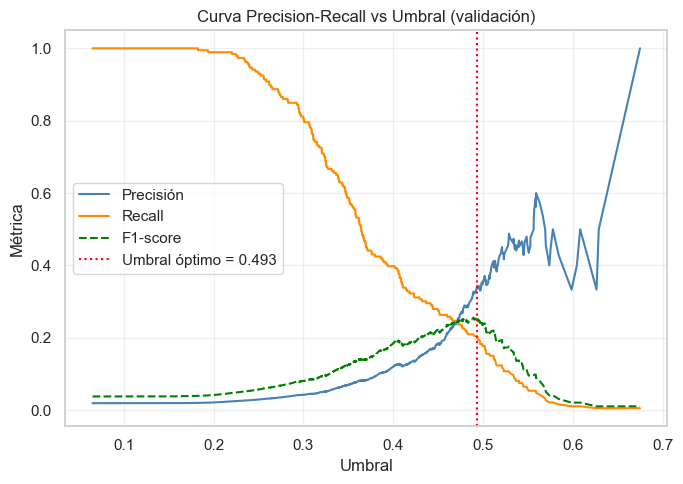

In [28]:
from sklearn.metrics import precision_recall_curve

# Predicciones de probabilidad sobre validación
pred_prob_val = modelo_clf_v2.predict(X_val, verbose=0).flatten()

# Calcular curva precision-recall
precision_arr, recall_arr, thresholds = precision_recall_curve(y_val_clf, pred_prob_val)

# F1 para cada umbral
f1_arr = (2 * precision_arr[:-1] * recall_arr[:-1]
          / (precision_arr[:-1] + recall_arr[:-1] + 1e-8))
umbral_optimo = float(thresholds[np.argmax(f1_arr)])
print(f"Umbral óptimo (max F1 en val): {umbral_optimo:.4f}")

# Graficar curva precision-recall
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(thresholds, precision_arr[:-1], label='Precisión', color='steelblue')
ax.plot(thresholds, recall_arr[:-1], label='Recall', color='darkorange')
ax.plot(thresholds, f1_arr, label='F1-score', color='green', linestyle='--')
ax.axvline(umbral_optimo, color='red', linestyle=':', label=f'Umbral óptimo = {umbral_optimo:.3f}')
ax.set_xlabel('Umbral')
ax.set_ylabel('Métrica')
ax.set_title('Curva Precision-Recall vs Umbral (validación)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(GRAFICAS_DIR / 'precision_recall_v2.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
from sklearn.metrics import roc_auc_score, f1_score, classification_report

# Predicciones sobre test con umbral óptimo
pred_prob_test_clf = modelo_clf_v2.predict(X_test, verbose=0).flatten()
pred_bin_v2 = (pred_prob_test_clf >= umbral_optimo).astype(int)

auc_v2 = roc_auc_score(y_test_clf, pred_prob_test_clf)
f1_v2  = f1_score(y_test_clf, pred_bin_v2)

print(f"AUC-ROC  v2: {auc_v2:.4f}")
print(f"F1-score v2: {f1_v2:.4f}")
print(f"Umbral usado: {umbral_optimo:.4f}")
print()
print(classification_report(y_test_clf, pred_bin_v2, target_names=['A tiempo', 'Retraso']))

AUC-ROC  v2: 0.6624
F1-score v2: 0.0952
Umbral usado: 0.4932

              precision    recall  f1-score   support

    A tiempo       0.92      0.97      0.94      8797
     Retraso       0.16      0.07      0.10       822

    accuracy                           0.89      9619
   macro avg       0.54      0.52      0.52      9619
weighted avg       0.85      0.89      0.87      9619



In [30]:
# Guardar modelo de clasificación v2
modelo_clf_v2.save(MODELS_DIR / 'modelo_clasificacion_v2.keras')
print("Modelo de clasificación v2 guardado en:", MODELS_DIR / 'modelo_clasificacion_v2.keras')

Modelo de clasificación v2 guardado en: ..\models\modelo_clasificacion_v2.keras


## 7. Visualizaciones v2

Tres paneles:
- **Izquierda**: predicción vs real (regresión)
- **Centro**: curva ROC v2
- **Derecha**: matriz de confusión con umbral óptimo

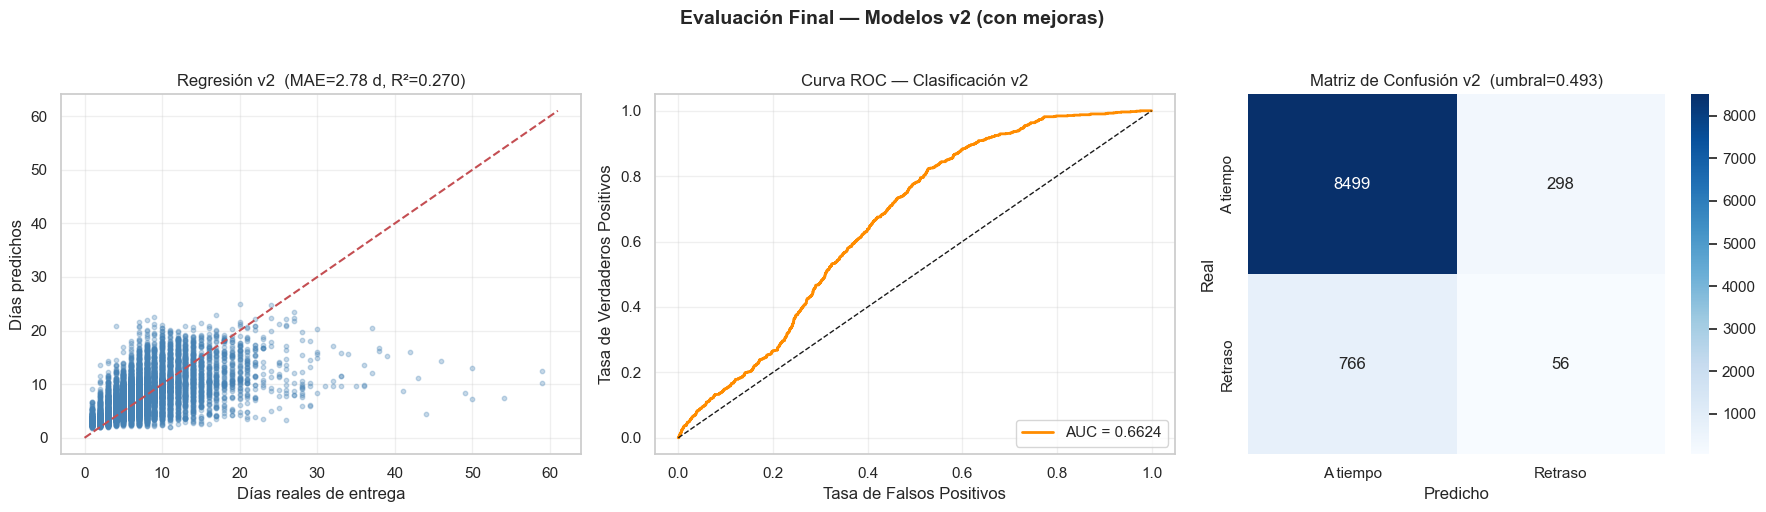

Figura guardada en: ..\outputs\graficas\evaluacion_v2.png


In [31]:
from sklearn.metrics import roc_curve, confusion_matrix
import seaborn as sns

# Predicciones de regresión en test
pred_reg_v2 = modelo_reg_v2.predict(X_test, verbose=0).flatten()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel 1: Scatter predicción vs real (regresión) ---
ax = axes[0]
ax.scatter(y_test_reg, pred_reg_v2, alpha=0.3, s=10, color='steelblue')
lim_max = max(y_test_reg.max(), pred_reg_v2.max()) + 2
ax.plot([0, lim_max], [0, lim_max], 'r--', linewidth=1.5)
ax.set_xlabel('Días reales de entrega')
ax.set_ylabel('Días predichos')
ax.set_title(f'Regresión v2  (MAE={mae_v2:.2f} d, R²={r2_v2:.3f})')
ax.grid(alpha=0.3)

# --- Panel 2: Curva ROC (clasificación) ---
ax = axes[1]
fpr, tpr, _ = roc_curve(y_test_clf, pred_prob_test_clf)
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc_v2:.4f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curva ROC — Clasificación v2')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

# --- Panel 3: Matriz de confusión ---
ax = axes[2]
cm = confusion_matrix(y_test_clf, pred_bin_v2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['A tiempo', 'Retraso'],
            yticklabels=['A tiempo', 'Retraso'])
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
ax.set_title(f'Matriz de Confusión v2  (umbral={umbral_optimo:.3f})')

plt.suptitle('Evaluación Final — Modelos v2 (con mejoras)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(GRAFICAS_DIR / 'evaluacion_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada en:", GRAFICAS_DIR / 'evaluacion_v2.png')

## 8. Tabla comparativa v1 vs v2

In [32]:
import json

# Cargar métricas v1
with open(OUTPUTS_DIR / 'metricas.json', 'r') as f:
    metricas_v1 = json.load(f)

mae_v1  = metricas_v1['regresion']['mae_dias']
rmse_v1 = metricas_v1['regresion']['rmse_dias']
r2_v1   = metricas_v1['regresion']['r2']
auc_v1  = metricas_v1['clasificacion']['auc_roc']
f1_v1   = metricas_v1['clasificacion']['f1_score']

# Construir tabla comparativa
datos_tabla = {
    'Modelo':   ['Regresión',  'Regresión',  'Regresión',
                 'Clasificación', 'Clasificación'],
    'Métrica':  ['MAE (días)', 'RMSE (días)', 'R²',
                 'AUC-ROC',   'F1-score'],
    'v1 (baseline)': [mae_v1, rmse_v1, r2_v1, auc_v1, f1_v1],
    'v2 (mejoras)':  [mae_v2, rmse_v2, r2_v2, auc_v2, f1_v2],
}

import pandas as pd
df_comp = pd.DataFrame(datos_tabla)
df_comp['Mejora'] = df_comp.apply(
    lambda row: f"{((row['v2 (mejoras)'] - row['v1 (baseline)']) / (abs(row['v1 (baseline)']) + 1e-8) * 100):+.1f}%",
    axis=1
)

pd.set_option('display.float_format', '{:.4f}'.format)
print(df_comp.to_string(index=False))

       Modelo     Métrica  v1 (baseline)  v2 (mejoras)  Mejora
    Regresión  MAE (días)         3.2555        2.7769  -14.7%
    Regresión RMSE (días)         4.3901        4.0796   -7.1%
    Regresión          R²         0.1546        0.2700  +74.6%
Clasificación     AUC-ROC         0.5565        0.6624  +19.0%
Clasificación    F1-score         0.0326        0.0952 +192.1%


In [33]:
# Guardar métricas v2 en JSON
metricas_v2 = {
    "regresion": {
        "mae_dias":  round(mae_v2,  4),
        "rmse_dias": round(rmse_v2, 4),
        "r2":        round(r2_v2,   4),
    },
    "clasificacion": {
        "auc_roc":      round(auc_v2, 4),
        "f1_score":     round(f1_v2,  4),
        "umbral_optimo": round(umbral_optimo, 4),
        "n_retrasos_reales":    int(y_test_clf.sum()),
        "n_retrasos_predichos": int(pred_bin_v2.sum()),
    },
    "mejoras_aplicadas": [
        "Feature dias_estimados (fecha_estimada - fecha_compra)",
        "Feature dias_limite_envio (shipping_limit_date - fecha_compra)",
        "Feature n_items (cantidad de ítems por orden)",
        "Feature mismo_estado (seller y customer en mismo estado)",
        "Focal Loss gamma=2.0, alpha=0.75 en clasificación",
        "Umbral óptimo via precision_recall_curve en lugar de 0.5",
    ],
    "features_nuevas": ["dias_estimados", "dias_limite_envio", "n_items", "mismo_estado"],
}

with open(OUTPUTS_DIR / 'metricas_v2.json', 'w', encoding='utf-8') as f:
    json.dump(metricas_v2, f, ensure_ascii=False, indent=2)

print("Métricas v2 guardadas en:", OUTPUTS_DIR / 'metricas_v2.json')
print(json.dumps(metricas_v2, indent=2, ensure_ascii=False))

Métricas v2 guardadas en: ..\outputs\metricas_v2.json
{
  "regresion": {
    "mae_dias": 2.7769,
    "rmse_dias": 4.0796,
    "r2": 0.27
  },
  "clasificacion": {
    "auc_roc": 0.6624,
    "f1_score": 0.0952,
    "umbral_optimo": 0.4932,
    "n_retrasos_reales": 822,
    "n_retrasos_predichos": 354
  },
  "mejoras_aplicadas": [
    "Feature dias_estimados (fecha_estimada - fecha_compra)",
    "Feature dias_limite_envio (shipping_limit_date - fecha_compra)",
    "Feature n_items (cantidad de ítems por orden)",
    "Feature mismo_estado (seller y customer en mismo estado)",
    "Focal Loss gamma=2.0, alpha=0.75 en clasificación",
    "Umbral óptimo via precision_recall_curve en lugar de 0.5"
  ],
  "features_nuevas": [
    "dias_estimados",
    "dias_limite_envio",
    "n_items",
    "mismo_estado"
  ]
}


## 9. Resumen de mejoras

### Cambios aplicados en v2

| Cambio | Descripción | Impacto esperado |
|--------|-------------|-----------------|
| `dias_estimados` | Diferencia entre fecha estimada y fecha de compra | Mayor impacto en regresión (R²) |
| `dias_limite_envio` | Días hasta el límite de envío del vendedor | Proxy de eficiencia logística |
| `n_items` | Cantidad de productos en la orden | Órdenes más grandes = más riesgo |
| `mismo_estado` | Vendedor y cliente en el mismo estado | Envíos locales son más rápidos |
| **Focal Loss** | Penaliza más los errores en la clase minoritaria (retrasos) | Mayor F1-score en clasificación |
| **Umbral óptimo** | Umbral seleccionado por máximo F1 en validación | Evita predecir siempre "a tiempo" |

### Por qué `dias_estimados` es la clave

La fecha estimada de entrega es calculada por Olist al momento de la compra usando su propio modelo logístico interno.  
Esa variable **encapsula toda la complejidad** del proceso (distancia, vendedor, historial) que el modelo v1 intentaba aprender desde cero.  
Al incluirla, el modelo sólo necesita aprender la **desviación** respecto a esa estimación, lo que simplifica enormemente el problema.

### Por qué fallaba la clasificación en v1

Con ~8% de retrasos y umbral=0.5, el modelo aprendía a predecir siempre "a tiempo" (accuracy=92%, F1≈0).  
La combinación de **Focal Loss** (durante el entrenamiento) + **umbral óptimo** (en la inferencia) corrige ambos lados del problema.